In [1]:
from pathlib import Path

dataset_path_root = Path('./Dataset').resolve()

dataset = [
    {
        "data_name": folder.stem,
        "root": str(folder.absolute()),
        "files": [
            str(list(subfolder.iterdir())[0])
            for subfolder in folder.iterdir()
            if subfolder.is_dir()
        ]
    }
    for folder in dataset_path_root.iterdir()
    if folder.is_dir()
]

dataset

[{'data_name': 'good quality',
  'root': 'C:\\Users\\Diana B\\Documents\\ProyectoNeuro\\Dataset\\good quality',
  'files': ['C:\\Users\\Diana B\\Documents\\ProyectoNeuro\\Dataset\\good quality\\5110156\\recon.nii']},
 {'data_name': 'placenta bad quality',
  'root': 'C:\\Users\\Diana B\\Documents\\ProyectoNeuro\\Dataset\\placenta bad quality',
  'files': ['C:\\Users\\Diana B\\Documents\\ProyectoNeuro\\Dataset\\placenta bad quality\\5143066\\recon.nii',
   'C:\\Users\\Diana B\\Documents\\ProyectoNeuro\\Dataset\\placenta bad quality\\5187149\\recon.nii',
   'C:\\Users\\Diana B\\Documents\\ProyectoNeuro\\Dataset\\placenta bad quality\\5188605\\recon.nii',
   'C:\\Users\\Diana B\\Documents\\ProyectoNeuro\\Dataset\\placenta bad quality\\5189896\\recon.nii']}]

In [2]:
dataset_reto_root = Path('./MRI_t2w_nii').resolve()

files = [file.absolute() for file in dataset_reto_root.glob('*.nii')]
files



[WindowsPath('C:/Users/Diana B/Documents/ProyectoNeuro/MRI_t2w_nii/t2-t21.00.nii'),
 WindowsPath('C:/Users/Diana B/Documents/ProyectoNeuro/MRI_t2w_nii/t2-t22.00.nii'),
 WindowsPath('C:/Users/Diana B/Documents/ProyectoNeuro/MRI_t2w_nii/t2-t23.00.nii'),
 WindowsPath('C:/Users/Diana B/Documents/ProyectoNeuro/MRI_t2w_nii/t2-t24.00.nii'),
 WindowsPath('C:/Users/Diana B/Documents/ProyectoNeuro/MRI_t2w_nii/t2-t25.00.nii')]

C:\Users\Diana B\Documents\ProyectoNeuro\MRI_t2w_nii\t2-t23.00.nii
(180, 221, 180)


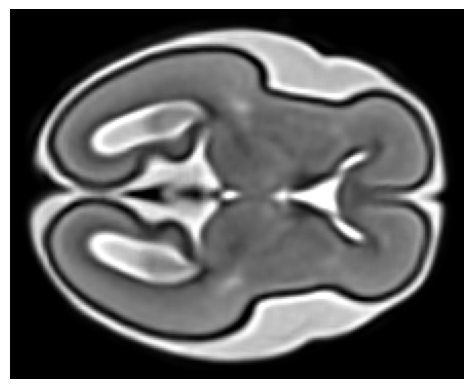

In [3]:
import nibabel as nib
import matplotlib.pyplot as plt

data = files[2]
print(data)

nii = nib.load(data)

volume = nii.get_fdata()

print(volume.shape)

slice_idx = volume.shape[2] // 2

plt.imshow(volume[:, :, slice_idx], cmap="gray")
plt.axis("off")
plt.show()

In [4]:
%matplotlib inline
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

def mostrar_corte(i):
    fig, ax = plt.subplots(1, 1, figsize=(6, 6))
    ax.imshow(volume[:, :, i].squeeze(), cmap="gray")
    ax.set_title(f"Slice {i}")
    ax.axis("off")
    plt.tight_layout()
    plt.show()

slider = widgets.IntSlider(value=0, min=0, max=volume.shape[2]-1, description="Slice:")
widgets.interact(mostrar_corte, i=slider)

interactive(children=(IntSlider(value=0, description='Slice:', max=179), Output()), _dom_classes=('widget-inte…

<function __main__.mostrar_corte(i)>

(139, 147, 128, 1)


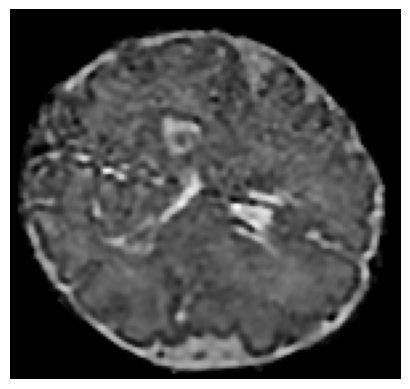

In [5]:
import nibabel as nib
import matplotlib.pyplot as plt


data = dataset[0]["files"][0]

nii = nib.load(data)

volume = nii.get_fdata()

print(volume.shape)

slice_idx = volume.shape[2] // 2

plt.imshow(volume[:, :, slice_idx], cmap="gray")
plt.axis("off")
plt.show()

In [6]:
print(nii.header)
print(nii.affine)
print(volume.dtype)
print(volume.shape)

<class 'nibabel.nifti1.Nifti1Header'> object, endian='<'
sizeof_hdr      : 348
data_type       : b''
db_name         : b''
extents         : 0
session_error   : 0
regular         : b'r'
dim_info        : 0
dim             : [  4 139 147 128   1   1   1   1]
intent_p1       : 0.0
intent_p2       : 0.0
intent_p3       : 0.0
intent_code     : none
datatype        : float64
bitpix          : 64
slice_start     : 0
pixdim          : [-1.          0.75000006  0.74999994  0.75        1.          0.
  0.          0.        ]
vox_offset      : 0.0
scl_slope       : nan
scl_inter       : nan
slice_end       : 0
slice_code      : unknown
xyzt_units      : 18
cal_max         : 0.0
cal_min         : 0.0
slice_duration  : 0.0
toffset         : 0.0
glmax           : 0
glmin           : 0
descrip         : b''
aux_file        : b''
qform_code      : scanner
sform_code      : unknown
quatern_b       : 0.1894734501838684
quatern_c       : 0.8745828866958618
quatern_d       : 0.43620428442955017
qoffset_

In [7]:
%matplotlib inline
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

def mostrar_corte(i):
    fig, ax = plt.subplots(1, 1, figsize=(6, 6))
    ax.imshow(volume[:, :, i].squeeze(), cmap="gray")
    ax.set_title(f"Slice {i}")
    ax.axis("off")
    plt.tight_layout()
    plt.show()

slider = widgets.IntSlider(value=0, min=0, max=volume.shape[2]-1, description="Slice:")
widgets.interact(mostrar_corte, i=slider)

interactive(children=(IntSlider(value=0, description='Slice:', max=127), Output()), _dom_classes=('widget-inte…

<function __main__.mostrar_corte(i)>

In [8]:
import numpy as np
from scipy.ndimage import convolve

def filtro_media(A: np.ndarray) -> np.ndarray:
    """Filtro de media 3×3 — suavizado uniforme."""
    w = np.ones((3, 3)) / 9
    return convolve(A.astype(float), w, mode='constant', cval=0.0)


def filtro_gaussiano(A: np.ndarray) -> np.ndarray:
    """Filtro gaussiano discreto 3×3."""
    w = np.array([[0.36, 0.6, 0.36],
                  [0.6,  1.0, 0.6 ],
                  [0.36, 0.6, 0.36]]) / 4.8976
    return convolve(A.astype(float), w, mode='constant', cval=0.0)


def filtro_sobel_x(A: np.ndarray) -> np.ndarray:
    """Filtro Sobel X — detecta bordes verticales."""
    w = np.array([[ 1,  0, -1],
                  [ 2,  0, -2],
                  [ 1,  0, -1]])
    return convolve(A.astype(float), w, mode='constant', cval=0.0)


def filtro_sobel_y(A: np.ndarray) -> np.ndarray:
    """Filtro Sobel Y — detecta bordes horizontales."""
    w = np.array([[ 1,  2,  1],
                  [ 0,  0,  0],
                  [-1, -2, -1]])
    return convolve(A.astype(float), w, mode='constant', cval=0.0)


def filtro_laplaciano_4(A: np.ndarray) -> np.ndarray:
    """Filtro Laplaciano-4 — detecta todos los bordes (suaves)."""
    w = np.array([[ 0,  1,  0],
                  [ 1, -4,  1],
                  [ 0,  1,  0]])
    return convolve(A.astype(float), w, mode='constant', cval=0.0)


def filtro_laplaciano_8(A: np.ndarray) -> np.ndarray:
    """Filtro Laplaciano-8 — detecta todos los bordes (pronunciados)."""
    w = np.array([[ 1,  1,  1],
                  [ 1, -8,  1],
                  [ 1,  1,  1]])
    return convolve(A.astype(float), w, mode='constant', cval=0.0)

def filtro_gamma(A: np.ndarray, gamma: float = 1.0) -> np.ndarray:
    """
    Corrección gamma: S = A^gamma  (imagen normalizada a [0, 1]).
      gamma < 1  →  realza zonas oscuras
      gamma > 1  →  realza zonas brillantes
      gamma = 1  →  sin cambio
    """
    A = A.astype(float)
    A_norm = (A - A.min()) / (A.max() - A.min() + 1e-8)  # normaliza a [0,1]
    return np.power(A_norm, gamma)


def filtro_log(A: np.ndarray, c: float = None) -> np.ndarray:
    """
    Transformación logarítmica: S = c * log(1 + A).
    Realza detalles en zonas oscuras y comprime los brillantes.
    Si c es None se calcula automáticamente para que la salida quede en [0, 1].
    """
    A = A.astype(float)
    A_norm = (A - A.min()) / (A.max() - A.min() + 1e-8)
    log_img = np.log1p(A_norm)
    if c is None:
        c = 1.0 / np.log1p(1.0)
    return c * log_img


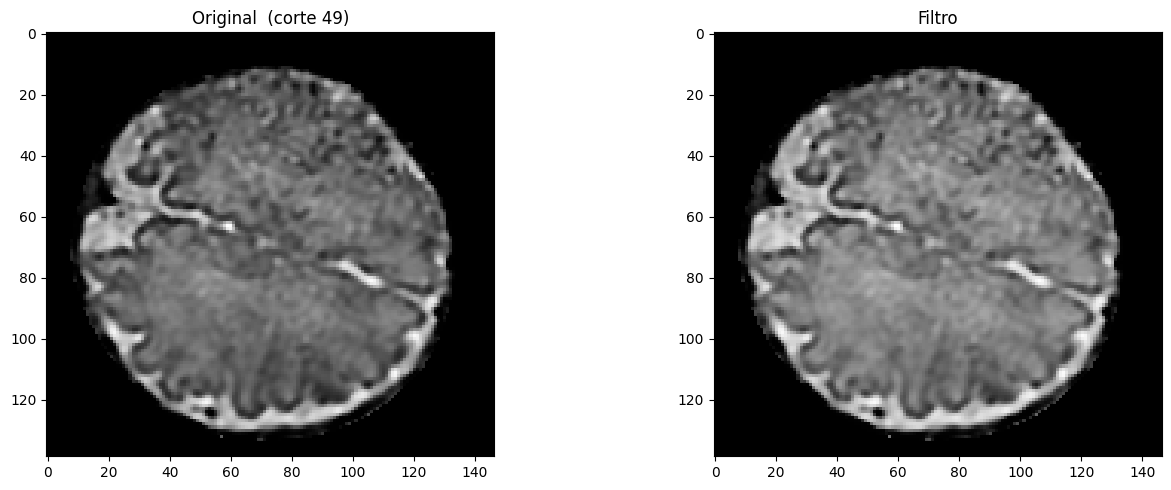

In [9]:
from IPython.display import display
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

for i in range(49, 50):
    img = np.array(volume[:, :, i]).squeeze()

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].imshow(img, cmap="gray")
    axes[0].set_title(f"Original  (corte {i})")
    axes[1].imshow(filtro_log(img), cmap="gray")
    axes[1].set_title("Filtro")

    plt.tight_layout()
    plt.show()

In [10]:
import nibabel as nib
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

data = dataset[0]["files"][0]

nii = nib.load(data)

volume = nii.get_fdata()

volume = np.squeeze(volume)

print("Shape:", volume.shape)

output_dir = Path("./MRI")
output_dir.mkdir(exist_ok=True)

# num_digits = len(str(volume.shape[2]))

# for i in range(volume.shape[2]):

#     img = volume[:, :, i]

#     img = (
#         (img - img.min()) /
#         (img.max() - img.min()) * 255
#     ).astype(np.uint8)

#     filename = f"slice_{i:0{num_digits}d}.png"

#     output_path = output_dir / filename

#     plt.imsave(
#         output_path,
#         img,
#         cmap="gray"
#     )

# print(f"Imágenes guardadas en: {output_dir.resolve()}")

Shape: (139, 147, 128)


In [11]:
from IPython.display import display
from itertools import chain
from pathlib import Path
from PIL import Image
import numpy as np
import cv2

def read_label(label_path: str):
    objects = []
    with open(label_path, 'r') as f:
        for line in f:
            parts = line.strip().split()
            class_id = int(parts[0])
            coords = list(map(float, parts[1:]))
            points = []
            for i in range(0, len(coords), 2):
                x = coords[i]
                y = coords[i + 1]
                points.append((x, y))
            objects.append({
                "class_id": class_id,
                "points": points
            })

    return objects


dataset_path_root = Path('./MRI_augmented').resolve() / 'train'
dataset_images = dataset_path_root / 'images'
dataset_labels = dataset_path_root / 'labels'


img_files = sorted(
    chain(
        dataset_images.glob("*.jpg"),
        dataset_images.glob("*.png")
    )
)
label_files = sorted(dataset_labels.glob('*.txt'))

dataset_files = list(zip(img_files, label_files))

In [12]:
import matplotlib.pyplot as plt

def compare_images(image1, image2, title1="Original", title2="Noise", figsize=(10, 5)):
    fig, axes = plt.subplots(1, 2, figsize=figsize)
    
    axes[0].imshow(image1, cmap='gray')
    axes[0].set_title(title1)
    axes[0].axis('off')
    
    axes[1].imshow(image2, cmap='gray')
    axes[1].set_title(title2)
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.show()

In [13]:
%matplotlib inline

import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display


def get_image(i):
    img = cv2.imread(str(dataset_files[i][0]), cv2.IMREAD_GRAYSCALE)
    labels = read_label(str(dataset_files[i][1]))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
    h, w = img.shape

    for obj in labels:
        pts = []
        for x_norm, y_norm in obj["points"]:
            x = int(x_norm * w)
            y = int(y_norm * h)
            pts.append([x, y])
        pts = np.array(pts, dtype=np.int32)
        cv2.polylines(img_rgb, [pts], isClosed=True, color=(255, 0, 0), thickness=2)

    return img, img_rgb


def mostrar_corte(i):

    fig, ax = plt.subplots(3, 3, figsize=(6, 10))

    img, slice_mask = get_image(i)

    slice_sobel_y       = filtro_sobel_y(img)
    slice_sobel_x       = filtro_sobel_x(img)
    slice_gamma         = filtro_gamma(img, gamma=0.5)
    slice_log           = filtro_log(img, c=5.0)
    slice_laplaciano_4  = filtro_laplaciano_4(img)
    slice_laplaciano_8  = filtro_laplaciano_8(img)
    slice_media         = filtro_media(img)
    slice_gaussiano     = filtro_gaussiano(img)

    images = [
        (img, "Original"),
        (slice_media, "Media"),
        (slice_gaussiano, "Gaussiano"),
        (slice_sobel_y, "Sobel Y"),
        (slice_sobel_x, "Sobel X"),
        (slice_gamma, "Gamma"),
        (slice_log, "Log"),
        (slice_laplaciano_4, "Laplaciano-4"),
        (slice_laplaciano_8, "Laplaciano-8"),
    ]

    for idx, (im, title) in enumerate(images):

        row = idx // 3
        col = idx % 3

        ax[row, col].imshow(im, cmap="gray")

        ax[row, col].set_title(f"{title} Slice {i}")

        ax[row, col].axis("off")

    plt.tight_layout()

    plt.show()


slider = widgets.IntSlider(
    value=0,
    min=0,
    max=len(dataset_files) - 1,
    description="Slice:"
)

widgets.interact(mostrar_corte, i=slider)

interactive(children=(IntSlider(value=0, description='Slice:', max=1999), Output()), _dom_classes=('widget-int…

<function __main__.mostrar_corte(i)>

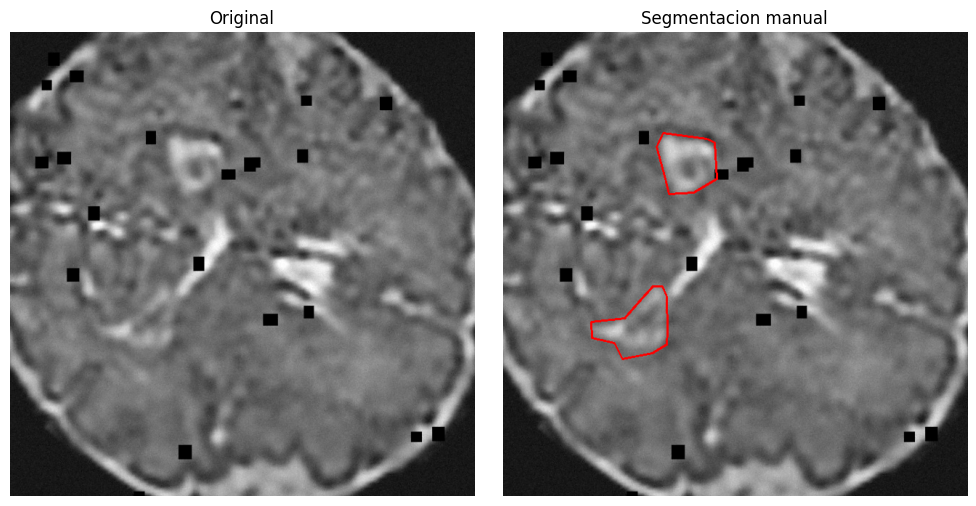

In [14]:
compare_images(get_image(2)[0], get_image(2)[1], title2="Segmentacion manual")

In [15]:
def kmeans_img(img: np.ndarray, k: int = 3):
    pixel_vals = img.reshape((-1,1))
    pixel_vals = np.float32(pixel_vals)

    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.85)

    retval, labels, centers = cv2.kmeans(pixel_vals, k, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)

    centers = np.uint8(centers)
    segmented_data = centers[labels.flatten()]

    segmented_image = segmented_data.reshape((img.shape))
    target_cluster = np.argmax(centers)

    segmented_mask = (
        labels.reshape(img.shape) == target_cluster
    )

    return segmented_image, segmented_mask

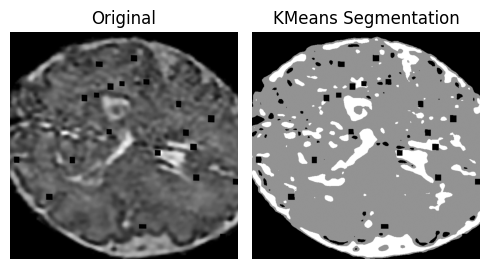

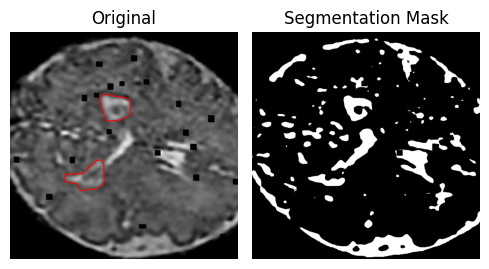

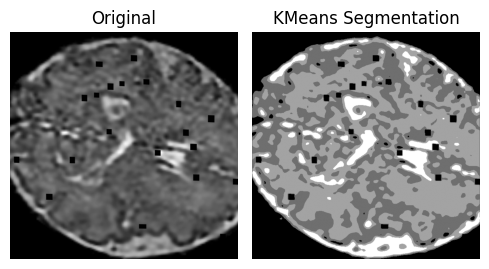

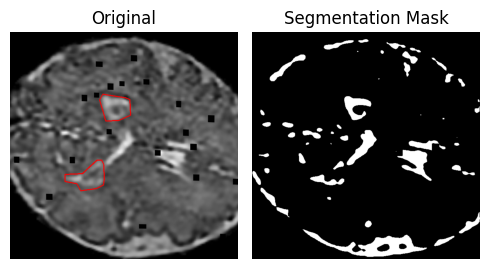

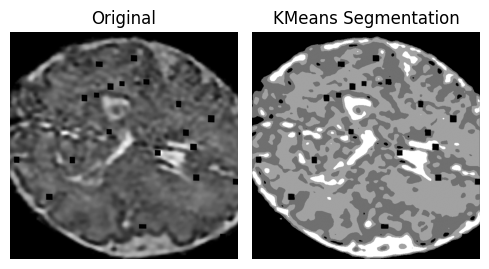

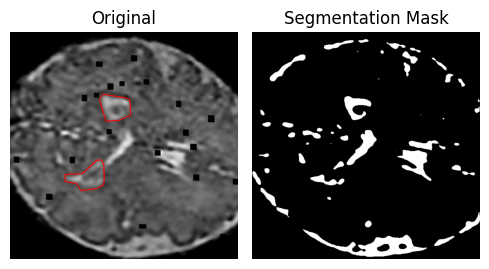

In [16]:
img, seg = get_image(8)

img_media = filtro_media(img)

img_gauss = filtro_gaussiano(img)

seg_img, seg_mask = kmeans_img(img)

compare_images(img, seg_img, title2="KMeans Segmentation", figsize=(5, 4))
compare_images(seg, seg_mask, title2="Segmentation Mask", figsize=(5, 4))

seg_img, seg_mask = kmeans_img(img_media, k=4)

compare_images(img, seg_img, title2="KMeans Segmentation", figsize=(5, 4))
compare_images(seg, seg_mask, title2="Segmentation Mask", figsize=(5, 4))

seg_img, seg_mask = kmeans_img(img_gauss, k=4)

compare_images(img, seg_img, title2="KMeans Segmentation", figsize=(5, 4))
compare_images(seg, seg_mask, title2="Segmentation Mask", figsize=(5, 4))

In [17]:
from pathlib import Path
from itertools import chain
import random
import cv2
import numpy as np
import albumentations as A
from tqdm import tqdm

# ============================================================
# CONFIGURACIÓN
# ============================================================

DATASET_ROOT = Path("./MRI.yolov11/train")

IMG_DIR = DATASET_ROOT / "images"
LBL_DIR = DATASET_ROOT / "labels"

OUT_ROOT = Path("./MRI_augmented")
OUT_IMG = OUT_ROOT / "images"
OUT_LBL = OUT_ROOT / "labels"

OUT_IMG.mkdir(parents=True, exist_ok=True)
OUT_LBL.mkdir(parents=True, exist_ok=True)

TARGET_IMAGES = 2000

# ============================================================
# LEER DATASET
# ============================================================

img_files = sorted(
    chain(
        IMG_DIR.glob("*.jpg"),
        IMG_DIR.glob("*.png")
    )
)

label_files = {
    p.stem: p
    for p in LBL_DIR.glob("*.txt")
}

pairs = [
    (img, label_files[img.stem])
    for img in img_files
    if img.stem in label_files
]

print(f"Imágenes encontradas: {len(pairs)}")

transform = A.Compose(
    [
        A.RandomResizedCrop(
            size=(640, 640),
            scale=(0.68, 1.0),
            ratio=(0.9, 1.1),
            p=1.0
        ),

        A.Rotate(
            limit=18,
            border_mode=cv2.BORDER_CONSTANT,
            p=0.8
        ),

        A.Affine(
            shear={
                "x": (-10, 10),
                "y": (-15, 15)
            },
            p=0.7
        ),

        A.RandomBrightnessContrast(
            brightness_limit=0.35,
            contrast_limit=0.0,
            p=0.7
        ),

        A.GaussianBlur(
            blur_limit=(1, 3),
            p=0.3
        ),

        A.GaussNoise(
            std_range=(0.01, 0.04),
            p=0.4
        ),

        A.CoarseDropout(
            num_holes_range=(20, 25),
            hole_height_range=(0.02, 0.03),
            hole_width_range=(0.02, 0.03),
            fill=0,
            p=0.5
        ),

        A.Perspective(
            scale=(0.02, 0.05),
            p=0.3
        ),
    ],
    keypoint_params=A.KeypointParams(
        format="xy",
        remove_invisible=False
    )
)

def load_yolo_segmentation(label_path, width, height):
    objects = []

    with open(label_path, "r") as f:
        for line in f:
            vals = line.strip().split()

            cls = int(vals[0])
            coords = list(map(float, vals[1:]))

            pts = []

            for i in range(0, len(coords), 2):
                x = coords[i] * width
                y = coords[i + 1] * height
                pts.append((x, y))

            objects.append((cls, pts))

    return objects


def save_yolo_segmentation(label_path, objects, width, height):

    with open(label_path, "w") as f:

        for cls, pts in objects:

            coords = []

            for x, y in pts:

                x = np.clip(x / width, 0, 1)
                y = np.clip(y / height, 0, 1)

                coords.extend([f"{x:.6f}", f"{y:.6f}"])

            f.write(f"{cls} " + " ".join(coords) + "\n")


n_original = len(pairs)
copies_per_image = int(np.ceil(TARGET_IMAGES / n_original))

counter = 0

for img_path, lbl_path in tqdm(pairs):

    image = cv2.imread(str(img_path))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    h, w = image.shape[:2]

    objects = load_yolo_segmentation(lbl_path, w, h)

    for aug_idx in range(copies_per_image):

        all_points = []
        owners = []

        for obj_id, (cls, pts) in enumerate(objects):
            for p in pts:
                all_points.append(p)
                owners.append((obj_id, cls))

        transformed = transform(
            image=image,
            keypoints=all_points
        )

        aug_img = transformed["image"]
        aug_points = transformed["keypoints"]

        new_objects = []

        idx = 0

        for cls, pts in objects:

            n_pts = len(pts)

            transformed_pts = aug_points[idx:idx+n_pts]

            idx += n_pts

            transformed_pts = [
                (
                    float(np.clip(x, 0, 639)),
                    float(np.clip(y, 0, 639))
                )
                for x, y in transformed_pts
            ]

            new_objects.append(
                (cls, transformed_pts)
            )

        img_name = f"mri_{counter:05d}.jpg"
        lbl_name = f"mri_{counter:05d}.txt"

        cv2.imwrite(
            str(OUT_IMG / img_name),
            cv2.cvtColor(aug_img, cv2.COLOR_RGB2BGR)
        )

        save_yolo_segmentation(
            OUT_LBL / lbl_name,
            new_objects,
            640,
            640
        )

        counter += 1

        if counter >= TARGET_IMAGES:
            break

    if counter >= TARGET_IMAGES:
        break

print(f"\nDataset generado: {counter} imágenes")
print(f"Imágenes: {OUT_IMG}")
print(f"Labels:   {OUT_LBL}")

Imágenes encontradas: 20


 95%|█████████▌| 19/20 [00:35<00:01,  1.89s/it]


Dataset generado: 2000 imágenes
Imágenes: MRI_augmented\images
Labels:   MRI_augmented\labels


In [18]:
import segmentation_models_pytorch as smp
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
import numpy as np
import random
import torch
import cv2

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights=None,
    in_channels=3,
    classes=1
).to(DEVICE)

model.load_state_dict(
    torch.load(
        "best_resnet34_unet.pt",
        map_location=DEVICE
    )
)

model.eval()


Unet(
  (encoder): ResNetEncoder(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05,

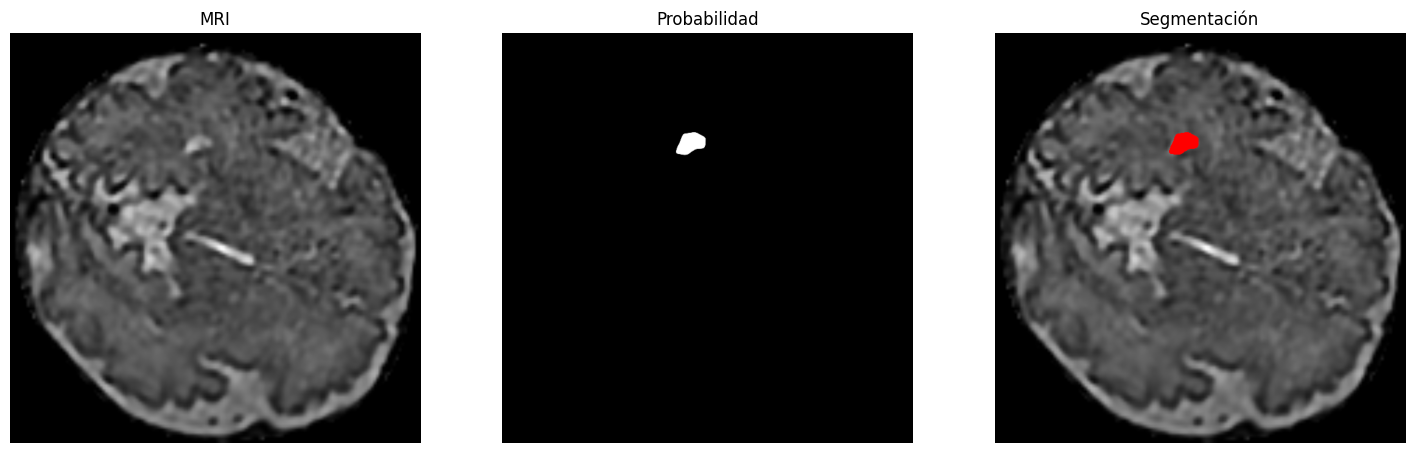

In [19]:

img_path = random.choice(list(Path("./MRI.yolov11/train/images").glob("*")))

image = Image.open(img_path).convert("RGB")
image = np.array(image)

image = cv2.resize(
    image,
    (640, 640),
    interpolation=cv2.INTER_LINEAR
)

h, w = image.shape[:2]

x = image.astype(np.float32) / 255.0
x = np.transpose(x, (2, 0, 1))
x = torch.tensor(x).unsqueeze(0).to(DEVICE)


with torch.no_grad():
    logits = model(x)
    probs = torch.sigmoid(logits)

mask = probs.squeeze().cpu().numpy()

mask_bin = (mask > 0.5).astype(np.uint8)


overlay = image.copy()

overlay[mask_bin == 1] = [
    255,
    0,
    0
]

fig, ax = plt.subplots(1, 3, figsize=(18, 6))

ax[0].imshow(image)
ax[0].set_title("MRI")

ax[1].imshow(mask, cmap="gray")
ax[1].set_title("Probabilidad")

ax[2].imshow(overlay)
ax[2].set_title("Segmentación")

for a in ax:
    a.axis("off")

plt.show()

In [20]:
from pathlib import Path
from PIL import Image
import numpy as np
import cv2
import torch

output_dir = Path("./output_segmentacion")
output_dir.mkdir(exist_ok=True)

img_paths = list(Path("./MRI.yolov11/train/images").glob("*"))

def seg_img(img_path):

    image = Image.open(img_path).convert("RGB")
    image = np.array(image)

    image = cv2.resize(
        image,
        (640, 640),
        interpolation=cv2.INTER_LINEAR
    )

    x = image.astype(np.float32) / 255.0
    x = np.transpose(x, (2, 0, 1))
    x = torch.tensor(x).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        logits = model(x)
        probs = torch.sigmoid(logits)

    mask = probs.squeeze().cpu().numpy()

    mask_bin = (mask > 0.5).astype(np.uint8)

    overlay = image.copy()
    overlay[mask_bin == 1] = [255, 0, 0]

    return image, mask_bin, overlay

for path in img_paths:

    img_name = path.stem.split(".rf")[0]

    print(f"Procesando: {img_name}")

    img, mask, overlay = seg_img(path)

    folder = output_dir / img_name
    folder.mkdir(exist_ok=True)

    cv2.imwrite(
        str(folder / "original.png"),
        cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
    )

    cv2.imwrite(
        str(folder / "mask.png"),
        mask * 255
    )

    cv2.imwrite(
        str(folder / "overlay.png"),
        cv2.cvtColor(overlay, cv2.COLOR_RGB2BGR)
    )

Procesando: slice_064_png
Procesando: slice_065_png
Procesando: slice_066_png
Procesando: slice_067_png
Procesando: slice_068_png
Procesando: slice_069_png
Procesando: slice_070_png
Procesando: slice_071_png
Procesando: slice_072_png
Procesando: slice_073_png
Procesando: slice_074_png
Procesando: slice_075_png
Procesando: slice_076_png
Procesando: slice_077_png
Procesando: slice_078_png
Procesando: slice_079_png
Procesando: slice_080_png
Procesando: slice_081_png
Procesando: slice_082_png
Procesando: slice_083_png


  0%|          | 0/20 [00:00<?, ?it/s]

Total píxeles (sin fondo): 298579
Min: 1
Max: 255
Media: 84.18239728848981
Std: 34.898855633128626


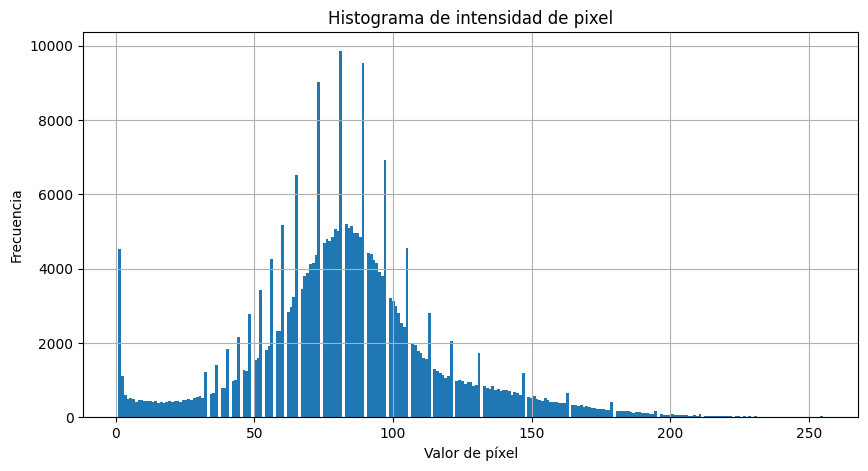

In [21]:
from pathlib import Path
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

img_paths = list(Path("./MRI.yolov11/train/images").glob("*"))

pixels = []

for img_path in tqdm(img_paths):

    img = Image.open(img_path).convert("L")
    arr = np.array(img)

    # quitar fondo
    arr = arr[arr > 0]

    if len(arr):
        pixels.append(arr)

pixels = np.concatenate(pixels)

print("Total píxeles (sin fondo):", len(pixels))
print("Min:", pixels.min())
print("Max:", pixels.max())
print("Media:", pixels.mean())
print("Std:", pixels.std())

plt.figure(figsize=(10, 5))
plt.hist(
    pixels,
    bins=255,
    range=(1, 255)
)

plt.title("Histograma de intensidad de pixel")
plt.xlabel("Valor de píxel")
plt.ylabel("Frecuencia")
plt.grid(True)

plt.show()

Pixel spacing : 0.750 x 0.750 mm
Shape NII     : (139, 147, 128, 1)
Slice original: 139 x 147 px
Escalas       : x=0.2172  y=0.2297
Device        : cuda

Procesando 20 imágenes...
Segmentación completa.



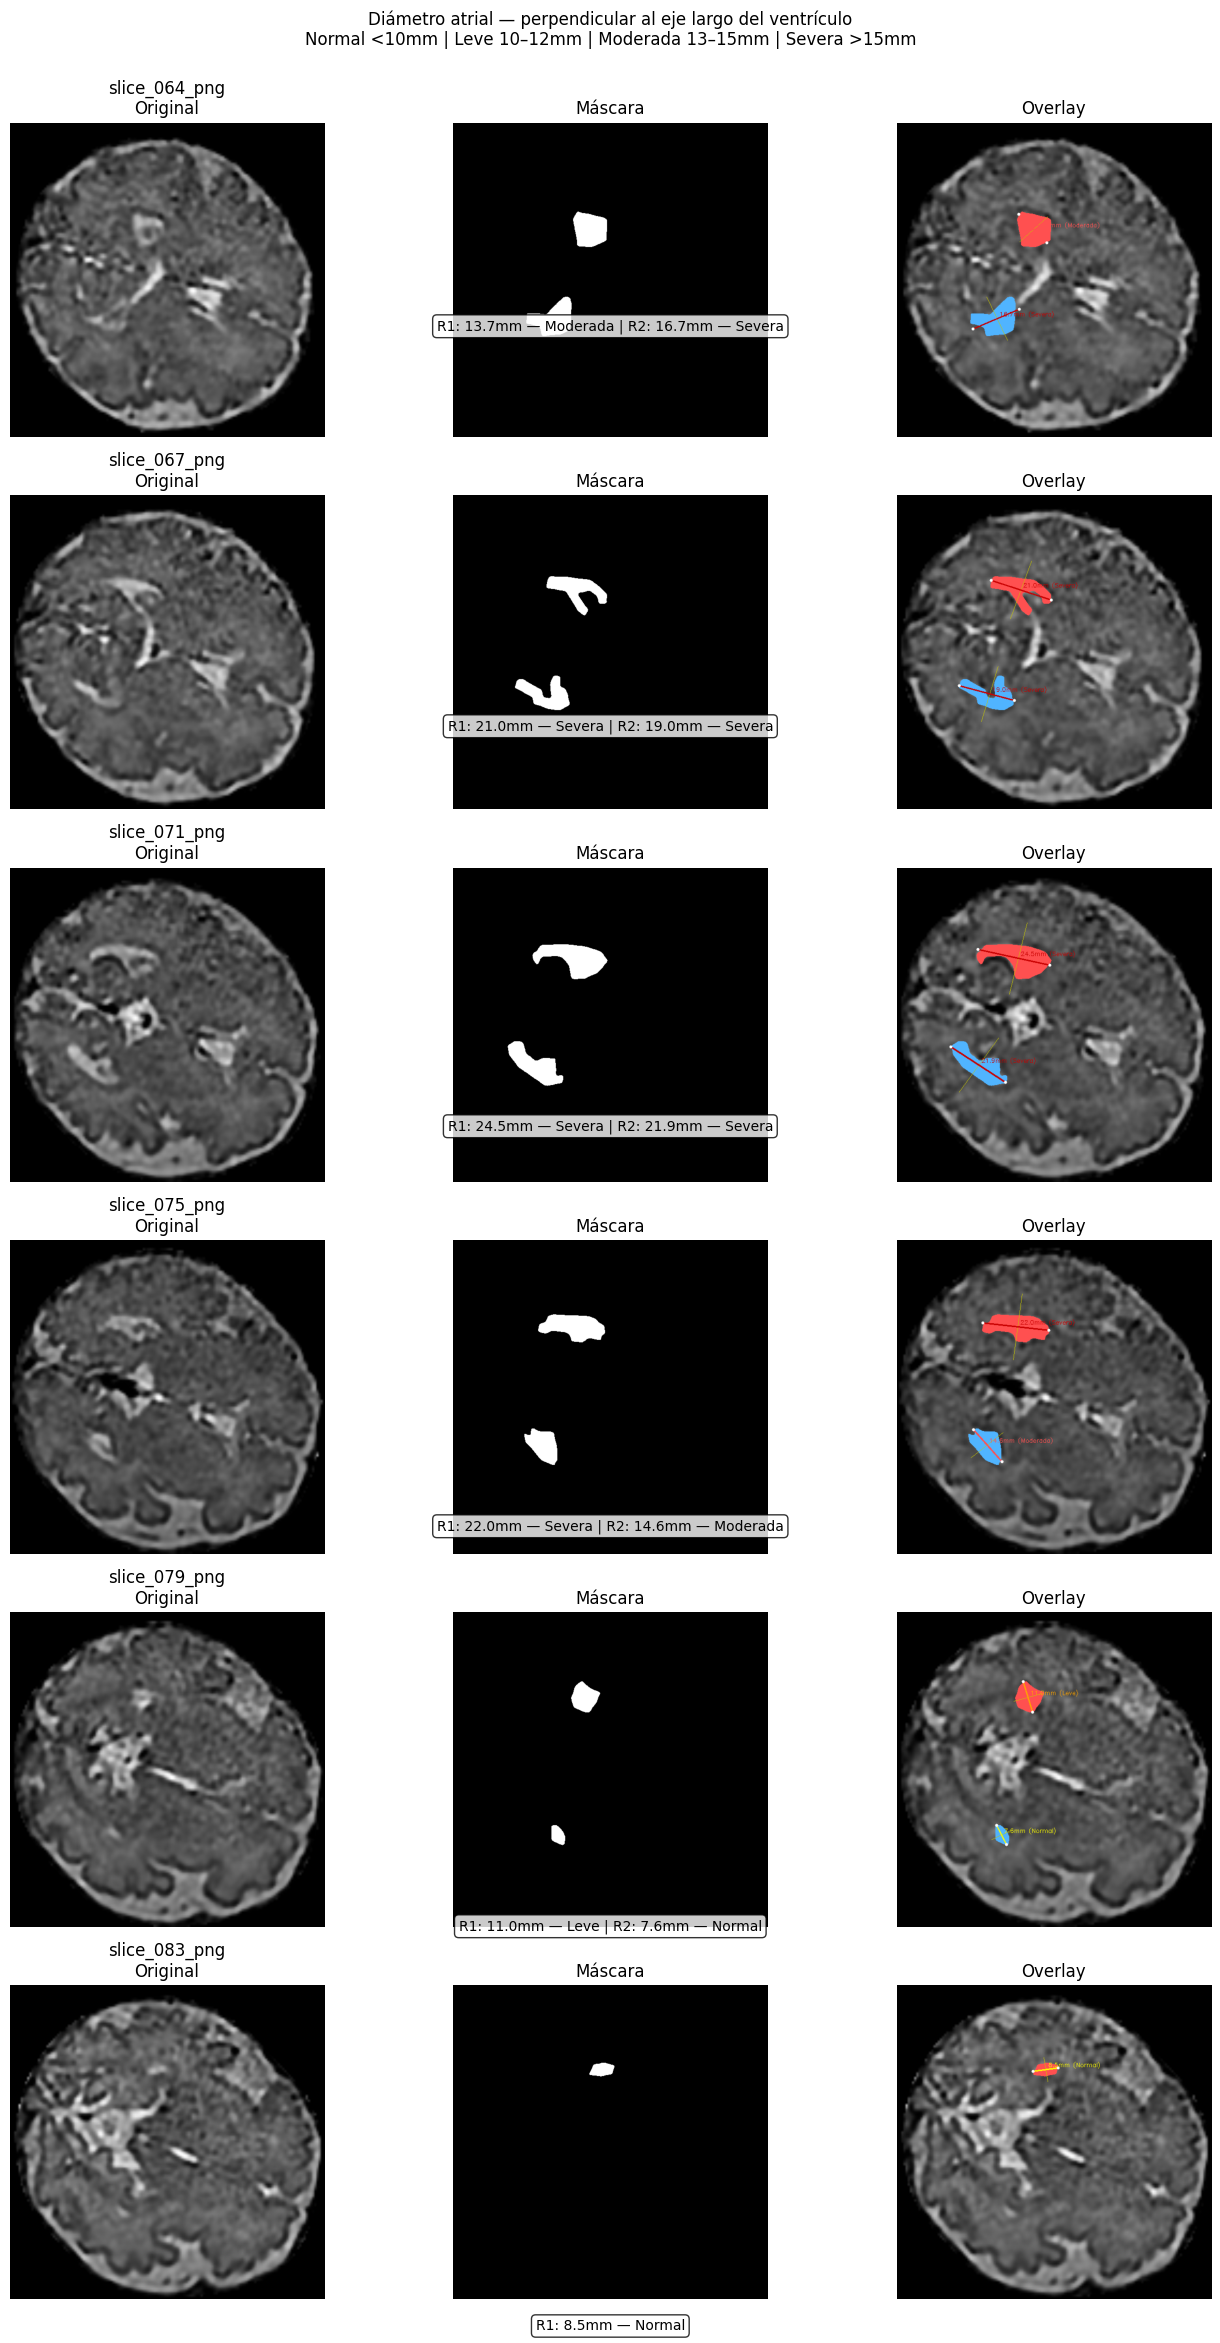


Slice                   R       mm Clasificación
--------------------------------------------------
slice_064_png           1   13.65mm     Moderada
slice_064_png           2   16.69mm       Severa
slice_065_png           1   15.88mm       Severa
slice_065_png           2   18.35mm       Severa
slice_066_png           1   16.13mm       Severa
slice_066_png           2   17.50mm       Severa
slice_067_png           1   20.95mm       Severa
slice_067_png           2   19.00mm       Severa
slice_068_png           1   23.05mm       Severa
slice_068_png           2   20.23mm       Severa
slice_069_png           1   24.30mm       Severa
slice_069_png           2   22.08mm       Severa
slice_070_png           1   23.98mm       Severa
slice_070_png           2   21.03mm       Severa
slice_071_png           1   24.50mm       Severa
slice_071_png           2   21.95mm       Severa
slice_072_png           1   23.54mm       Severa
slice_072_png           2   21.69mm       Severa
slice_073_png    

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
from skimage.measure import label, regionprops
import torch
import nibabel as nib
import csv

NII_PATH    = "./Dataset/good quality/5110156/recon.nii"
IMG_DIR    = Path("./MRI.yolov11/train/images")
OUTPUT_DIR = Path("./output_segmentacion")
DEVICE     = "cuda" if torch.cuda.is_available() else "cpu"
MODEL_SIZE = 640
OUTPUT_DIR.mkdir(exist_ok=True)

nii      = nib.load(NII_PATH)
hdr      = nii.header
pixdim   = hdr.get_zooms()
px_mm_x  = abs(float(pixdim[0]))
px_mm_y  = abs(float(pixdim[1]))
nii_shape           = nii.shape
orig_h, orig_w      = nii_shape[1], nii_shape[0]
scale_x = orig_w / MODEL_SIZE
scale_y = orig_h / MODEL_SIZE

print(f"Pixel spacing : {px_mm_x:.3f} x {px_mm_y:.3f} mm")
print(f"Shape NII     : {nii_shape}")
print(f"Slice original: {orig_w} x {orig_h} px")
print(f"Escalas       : x={scale_x:.4f}  y={scale_y:.4f}")
print(f"Device        : {DEVICE}")

def clasificar_vm(d_mm):
    if d_mm < 10:
        return "Normal"
    elif d_mm <= 12:
        return "Leve"
    elif d_mm <= 15:
        return "Moderada"
    else:
        return "Severa"

COLORES_CLAS = {
    "Normal":   (255, 255,   0),
    "Leve":     (255, 165,   0),
    "Moderada": (255,  80,  80),
    "Severa":   (200,   0,   0),
}

def seg_img(img_path):
    image      = Image.open(img_path).convert("RGB")
    orig_size  = image.size
    image_res  = np.array(image.resize((MODEL_SIZE, MODEL_SIZE), Image.BILINEAR))
    x = torch.tensor(
            np.transpose(image_res.astype(np.float32) / 255.0, (2, 0, 1))
        ).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        probs    = torch.sigmoid(model(x))
        mask_bin = (probs.squeeze().cpu().numpy() > 0.5).astype(np.uint8)
    overlay = image_res.copy()
    overlay[mask_bin == 1] = [255, 0, 0]
    return image_res, mask_bin, overlay, orig_size

img_paths = list(IMG_DIR.glob("*"))
print(f"\nProcesando {len(img_paths)} imágenes...")
for path in img_paths:
    img_name = path.stem.split(".rf")[0]
    img, mask, overlay, _ = seg_img(path)
    folder = OUTPUT_DIR / img_name
    folder.mkdir(exist_ok=True)
    cv2.imwrite(str(folder / "original.png"), cv2.cvtColor(img, cv2.COLOR_RGB2BGR))
    cv2.imwrite(str(folder / "mask.png"),     mask * 255)
    cv2.imwrite(str(folder / "overlay.png"),  cv2.cvtColor(overlay, cv2.COLOR_RGB2BGR))
print("Segmentación completa.\n")

def eje_y_diametro_real(region, scale_x, scale_y, px_mm_x, px_mm_y):
    angle  = region.orientation
    cy, cx = region.centroid

    cy_r = cy * scale_y
    cx_r = cx * scale_x
    a_r  = (region.axis_major_length / 2) * ((scale_x + scale_y) / 2)

    eje_largo = np.array([-np.sin(angle),  np.cos(angle)])
    eje_corto = np.array([ np.cos(angle),  np.sin(angle)])

    coords_orig = region.coords * np.array([scale_y, scale_x])
    coords_c    = coords_orig - np.array([cy_r, cx_r])
    proj        = coords_c @ eje_corto
    proj_min, proj_max = proj.min(), proj.max()

    def to_draw(pv):
        pt = np.array([cy_r, cx_r]) + pv * eje_corto
        return (int(pt[1] / scale_x), int(pt[0] / scale_y))

    p1_draw = to_draw(proj_min)
    p2_draw = to_draw(proj_max)

    diametro_mm = (proj_max - proj_min) * ((px_mm_x + px_mm_y) / 2)

    return (cy, cx), eje_largo, eje_corto, diametro_mm, p1_draw, p2_draw, a_r

slices        = sorted(OUTPUT_DIR.glob("slice_*"))
n_sample      = 6
sample_slices = [slices[i] for i in np.linspace(0, len(slices)-1, n_sample, dtype=int)]
colores_reg   = [(255, 80, 80), (80, 180, 255), (80, 255, 130)]

fig, axes = plt.subplots(n_sample, 3, figsize=(14, n_sample * 4))
fig.suptitle(
    "Diámetro atrial — perpendicular al eje largo del ventrículo\n"
    "Normal <10mm | Leve 10–12mm | Moderada 13–15mm | Severa >15mm",
    fontsize=12
)

for row, slice_dir in enumerate(sample_slices):
    original = cv2.imread(str(slice_dir / "original.png"), cv2.IMREAD_GRAYSCALE)
    mask_raw = cv2.imread(str(slice_dir / "mask.png"),     cv2.IMREAD_GRAYSCALE)
    _, mask  = cv2.threshold(mask_raw, 10, 255, cv2.THRESH_BINARY)
    overlay  = cv2.cvtColor(original, cv2.COLOR_GRAY2RGB)
    regions  = [r for r in regionprops(label(mask > 0)) if r.area > 50]

    medidas_texto = []

    for i, region in enumerate(regions):
        for r, c in region.coords:
            overlay[r, c] = colores_reg[i % len(colores_reg)]

        (cy, cx), eje_largo, _, d_mm, p1, p2, a_r = \
            eje_y_diametro_real(region, scale_x, scale_y, px_mm_x, px_mm_y)

        clas        = clasificar_vm(d_mm)
        label_color = COLORES_CLAS[clas]

        cv2.line(overlay,
                 (int(cx - (a_r/scale_x)*eje_largo[1]), int(cy - (a_r/scale_y)*eje_largo[0])),
                 (int(cx + (a_r/scale_x)*eje_largo[1]), int(cy + (a_r/scale_y)*eje_largo[0])),
                 (200, 200, 0), 1)
        cv2.line(overlay, p1, p2, label_color, 2)
        cv2.circle(overlay, p1, 3, (255, 255, 255), -1)
        cv2.circle(overlay, p2, 3, (255, 255, 255), -1)
        # etiqueta
        cv2.putText(overlay, f"{d_mm:.1f}mm ({clas})",
                    (int(cx) + 5, int(cy) - 5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.40, label_color, 1)

        medidas_texto.append(f"R{i+1}: {d_mm:.1f}mm — {clas}")

    axes[row, 0].imshow(original, cmap="gray")
    axes[row, 0].set_title(f"{slice_dir.name}\nOriginal")
    axes[row, 0].axis("off")

    axes[row, 1].imshow(mask, cmap="gray")
    axes[row, 1].set_title("Máscara")
    axes[row, 1].axis("off")

    axes[row, 2].imshow(overlay)
    axes[row, 2].set_title("Overlay")
    axes[row, 2].axis("off")

    texto = " | ".join(medidas_texto) if medidas_texto else "Sin regiones detectadas"
    fig.text(
        0.5, 1 - ((row + 0.92) / n_sample),
        texto, ha="center", fontsize=10,
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
    )

plt.tight_layout(rect=[0, 0.02, 1, 0.98])
plt.savefig("resultado_diametro_mm.png", dpi=150, bbox_inches="tight")
plt.show()

rows_csv = []
for slice_dir in slices:
    mask_raw = cv2.imread(str(slice_dir / "mask.png"), cv2.IMREAD_GRAYSCALE)
    _, mask  = cv2.threshold(mask_raw, 10, 255, cv2.THRESH_BINARY)
    regions  = [r for r in regionprops(label(mask > 0)) if r.area > 50]
    for i, region in enumerate(regions):
        _, _, _, d_mm, _, _, _ = eje_y_diametro_real(region, scale_x, scale_y, px_mm_x, px_mm_y)
        rows_csv.append({
            "slice":            slice_dir.name,
            "region":           i + 1,
            "diametro_mm":      round(d_mm, 2),
            "clasificacion":    clasificar_vm(d_mm),
            "ventriculomegalia": d_mm >= 10,
        })

with open("diametros.csv", "w", newline="") as f:
    writer = csv.DictWriter(
        f, fieldnames=["slice", "region", "diametro_mm", "clasificacion", "ventriculomegalia"]
    )
    writer.writeheader()
    writer.writerows(rows_csv)

print(f"\n{'Slice':<22} {'R':>2} {'mm':>8} {'Clasificación':>12}")
print("-" * 50)
for r in rows_csv:
    print(f"{r['slice']:<22} {r['region']:>2} {r['diametro_mm']:>7.2f}mm {r['clasificacion']:>12}")

print("\nGuardado: resultado_diametro_mm.png  |  diametros.csv")

In [24]:
import pandas as pd
import numpy as np

hdr = nii.header

matriz = tuple(hdr["dim"][1:4])

res_x = float(hdr["pixdim"][1])
res_y = float(hdr["pixdim"][2])
res_z = float(hdr["pixdim"][3])

datatype = str(hdr.get_data_dtype())
bits = int(hdr["bitpix"])

tabla = pd.DataFrame({
    "Parámetro": [
        "Tamaño de matriz",
        "Resolución espacial X",
        "Resolución espacial Y",
        "Resolución espacial Z",
        "Resolución de intensidad",
        "Tipo de dato"
    ],
    "Valor": [
        f"{matriz[0]} × {matriz[1]} × {matriz[2]}",
        f"{res_x:.3f} mm/voxel",
        f"{res_y:.3f} mm/voxel",
        f"{res_z:.3f} mm/voxel",
        f"{bits} bits",
        datatype
    ]
})

display(tabla)
tabla.to_csv("caracteristicas_imagen.csv", index=False)
tabla

,Parámetro,Valor
0,Tamaño de matriz,139 × 147 × 128
1,Resolución espacial X,0.750 mm/voxel
2,Resolución espacial Y,0.750 mm/voxel
3,Resolución espacial Z,0.750 mm/voxel
4,Resolución de intensidad,64 bits
5,Tipo de dato,float64


,Parámetro,Valor
0,Tamaño de matriz,139 × 147 × 128
1,Resolución espacial X,0.750 mm/voxel
2,Resolución espacial Y,0.750 mm/voxel
3,Resolución espacial Z,0.750 mm/voxel
4,Resolución de intensidad,64 bits
5,Tipo de dato,float64


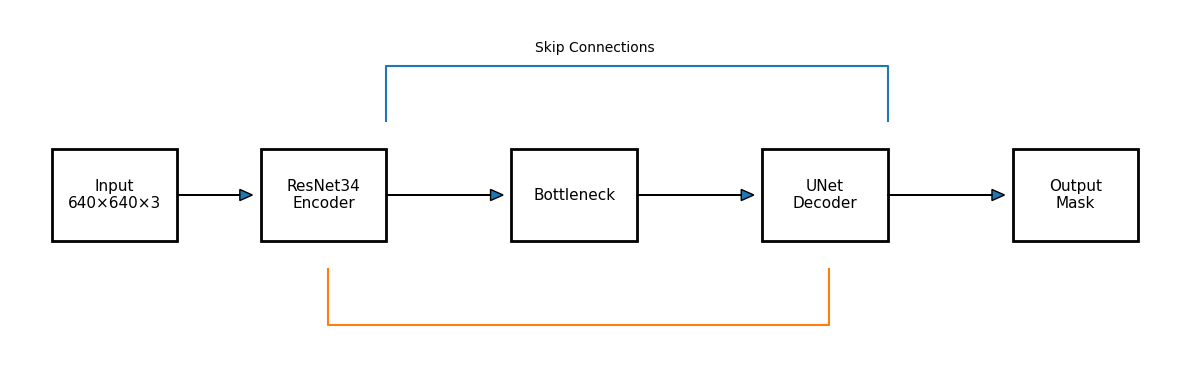

In [25]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

fig, ax = plt.subplots(figsize=(12, 4))

ax.set_xlim(0, 14)
ax.set_ylim(0, 4)
ax.axis("off")

bloques = [
    (0.5, "Input\n640×640×3"),
    (3.0, "ResNet34\nEncoder"),
    (6.0, "Bottleneck"),
    (9.0, "UNet\nDecoder"),
    (12.0, "Output\nMask")
]

for x, texto in bloques:
    rect = Rectangle(
        (x, 1.5),
        1.5,
        1,
        fill=False,
        linewidth=2
    )
    ax.add_patch(rect)

    ax.text(
        x + 0.75,
        2.0,
        texto,
        ha="center",
        va="center",
        fontsize=11
    )

for i in range(len(bloques) - 1):
    x1 = bloques[i][0] + 1.5
    x2 = bloques[i + 1][0]

    ax.arrow(
        x1,
        2.0,
        x2 - x1 - 0.1,
        0,
        length_includes_head=True,
        head_width=0.12,
        head_length=0.15
    )

# Skip connections
ax.plot([4.5, 4.5, 10.5, 10.5], [2.8, 3.4, 3.4, 2.8], linewidth=1.5)
ax.plot([3.8, 3.8, 9.8, 9.8], [1.2, 0.6, 0.6, 1.2], linewidth=1.5)

ax.text(
    7,
    3.55,
    "Skip Connections",
    ha="center",
    fontsize=10
)

plt.tight_layout()

plt.savefig(
    "resnet34_unet_architecture.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    "resnet34_unet_architecture.pdf",
    bbox_inches="tight"
)

plt.show()